# TP: Predicción de Porcentaje de Grasa Corporal
## Aprendizaje de Máquina — Maestría en Inteligencia Artificial

**Dataset:** Body Fat Dataset  
**Observaciones:** 252  
**Variables:** 15 (Density, BodyFat, Age, Weight, Height, Neck, Chest, Abdomen, Hip, Thigh, Knee, Ankle, Biceps, Forearm, Wrist)  
**Target:** `BodyFat` — porcentaje de grasa corporal

---
## FASE 1: Entendimiento y Configuración

### 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — módulos base
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Librerías importadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ Librerías importadas correctamente
   pandas  3.0.3
   numpy   2.4.6
   seaborn 0.13.2


### 2. Carga e inspección básica

In [2]:
# ⚠️ Ajustá la ruta al archivo según tu entorno
df = pd.read_csv('bodyfat.csv')

print(f'Shape del dataset: {df.shape}')
df.head(10)

Shape del dataset: (252, 15)


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
5,1.0502,20.9,24,210.25,74.75,39.0,104.5,94.4,107.8,66.0,42.0,25.6,35.7,30.6,18.8
6,1.0549,19.2,26,181.00,69.75,36.4,105.1,90.7,100.3,58.4,38.3,22.9,31.9,27.8,17.7
7,1.0704,12.4,25,176.00,72.50,37.8,99.6,88.5,97.1,60.0,39.4,23.2,30.5,29.0,18.8
8,1.0900,4.1,25,191.00,74.00,38.1,100.9,82.5,99.9,62.9,38.3,23.8,35.9,31.1,18.2
9,1.0722,11.7,23,198.25,73.50,42.1,99.6,88.6,104.1,63.1,41.7,25.0,35.6,30.0,19.2


In [3]:
# Información de tipos y valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [4]:
# Estadísticas descriptivas completas
df.describe().round(3)

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000
mean,1.056,19.151,44.885,178.924,70.149,37.992,100.824,92.556,99.905,59.406,38.590,23.102,32.273,28.664,18.230
std,0.019,8.369,12.602,29.389,3.663,2.431,8.430,10.783,7.164,5.250,2.412,1.695,3.021,2.021,0.934
min,0.995,0.000,22.000,118.500,29.500,31.100,79.300,69.400,85.000,47.200,33.000,19.100,24.800,21.000,15.800
25%,1.041,12.475,35.750,159.000,68.250,36.400,94.350,84.575,95.500,56.000,36.975,22.000,30.200,27.300,17.600
50%,1.055,19.200,43.000,176.500,70.000,38.000,99.650,90.950,99.300,59.000,38.500,22.800,32.050,28.700,18.300
75%,1.070,25.300,54.000,197.000,72.250,39.425,105.375,99.325,103.525,62.350,39.925,24.000,34.325,30.000,18.800
max,1.109,47.500,81.000,363.150,77.750,51.200,136.200,148.100,147.700,87.300,49.100,33.900,45.000,34.900,21.400


In [5]:
# Verificación de nulos explícitos y strings ocultos
print('=== Valores nulos por columna ===')
print(df.isnull().sum())

print('\n=== Verificación de tipos por columna ===')
for col in df.columns:
    non_numeric = pd.to_numeric(df[col], errors='coerce').isna().sum()
    if non_numeric > 0:
        print(f'  ⚠️  {col}: {non_numeric} valores no numéricos detectados')
    else:
        print(f'  ✅ {col}: OK')

=== Valores nulos por columna ===
Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

=== Verificación de tipos por columna ===
  ✅ Density: OK
  ✅ BodyFat: OK
  ✅ Age: OK
  ✅ Weight: OK
  ✅ Height: OK
  ✅ Neck: OK
  ✅ Chest: OK
  ✅ Abdomen: OK
  ✅ Hip: OK
  ✅ Thigh: OK
  ✅ Knee: OK
  ✅ Ankle: OK
  ✅ Biceps: OK
  ✅ Forearm: OK
  ✅ Wrist: OK


---
## FASE 2: Análisis Exploratorio de Datos (EDA)

### 4. Detección de anomalías biológicas — BodyFat = 0.0

In [7]:
# Identificar filas con BodyFat <= 0 (biológicamente imposible)
anomalias_bodyfat = df[df['BodyFat'] <= 0]

print(f'Filas con BodyFat <= 0: {len(anomalias_bodyfat)}')
print()
print(anomalias_bodyfat)

Filas con BodyFat <= 0: 1

     Density  BodyFat  Age  Weight  Height  Neck  Chest  Abdomen   Hip  Thigh  \
181   1.1089      0.0   40   118.5    68.0  33.8   79.3     69.4  85.0   47.2   

     Knee  Ankle  Biceps  Forearm  Wrist  
181  33.5   20.2    27.7     24.6   16.5  


In [8]:
# DECISIÓN: Eliminar la fila con BodyFat = 0 por ser biológicamente inválida.
# Un ser humano vivo necesariamente tiene grasa corporal esencial (>2% en hombres).
# Imputar con la media podría sesgar el modelo; la eliminación es más conservadora.

df_clean = df[df['BodyFat'] > 0].copy()

print(f'Shape original : {df.shape}')
print(f'Shape limpio   : {df_clean.shape}')
print(f'Filas eliminadas: {df.shape[0] - df_clean.shape[0]}')

Shape original : (252, 15)
Shape limpio   : (251, 15)
Filas eliminadas: 1


### 5. Revisión de valores extremos — Weight y Height

In [9]:
# --- Peso máximo ---
max_weight_idx = df_clean['Weight'].idxmax()
print('=== Individuo con mayor peso (363.15 lbs ≈ 164.7 kg) ===')
print(df_clean.loc[max_weight_idx])
print()

# --- Altura mínima ---
min_height_idx = df_clean['Height'].idxmin()
print('=== Individuo con menor altura (29.5 pulgadas ≈ 74.9 cm) ===')
print(df_clean.loc[min_height_idx])

=== Individuo con mayor peso (363.15 lbs ≈ 164.7 kg) ===
Density      1.0202
BodyFat     35.2000
Age         46.0000
Weight     363.1500
Height      72.2500
Neck        51.2000
Chest      136.2000
Abdomen    148.1000
Hip        147.7000
Thigh       87.3000
Knee        49.1000
Ankle       29.6000
Biceps      45.0000
Forearm     29.0000
Wrist       21.4000
Name: 38, dtype: float64

=== Individuo con menor altura (29.5 pulgadas ≈ 74.9 cm) ===
Density      1.025
BodyFat     32.900
Age         44.000
Weight     205.000
Height      29.500
Neck        36.600
Chest      106.000
Abdomen    104.300
Hip        115.500
Thigh       70.600
Knee        42.500
Ankle       23.700
Biceps      33.600
Forearm     28.700
Wrist       17.400
Name: 41, dtype: float64


In [10]:
# Análisis: Height = 29.5 pulgadas es un error evidente de tipeo
# (equivale a ~75 cm, incompatible con el peso y medidas del individuo).
# La mediana del dataset es 70 pulgadas. Imputamos con la mediana.

mediana_height = df_clean['Height'].median()
print(f'Mediana de Height: {mediana_height} pulgadas')

df_clean.loc[min_height_idx, 'Height'] = mediana_height
print(f'Height corregida para índice {min_height_idx}: {df_clean.loc[min_height_idx, "Height"]}')

# El peso máximo (363.15 lbs) es extremo pero plausible;
# su BodyFat es consistente con las demás medidas → se conserva.
print('\n⚠️  Weight = 363.15 lbs: valor extremo pero biológicamente plausible → se conserva.')

Mediana de Height: 70.0 pulgadas
Height corregida para índice 41: 70.0

⚠️  Weight = 363.15 lbs: valor extremo pero biológicamente plausible → se conserva.


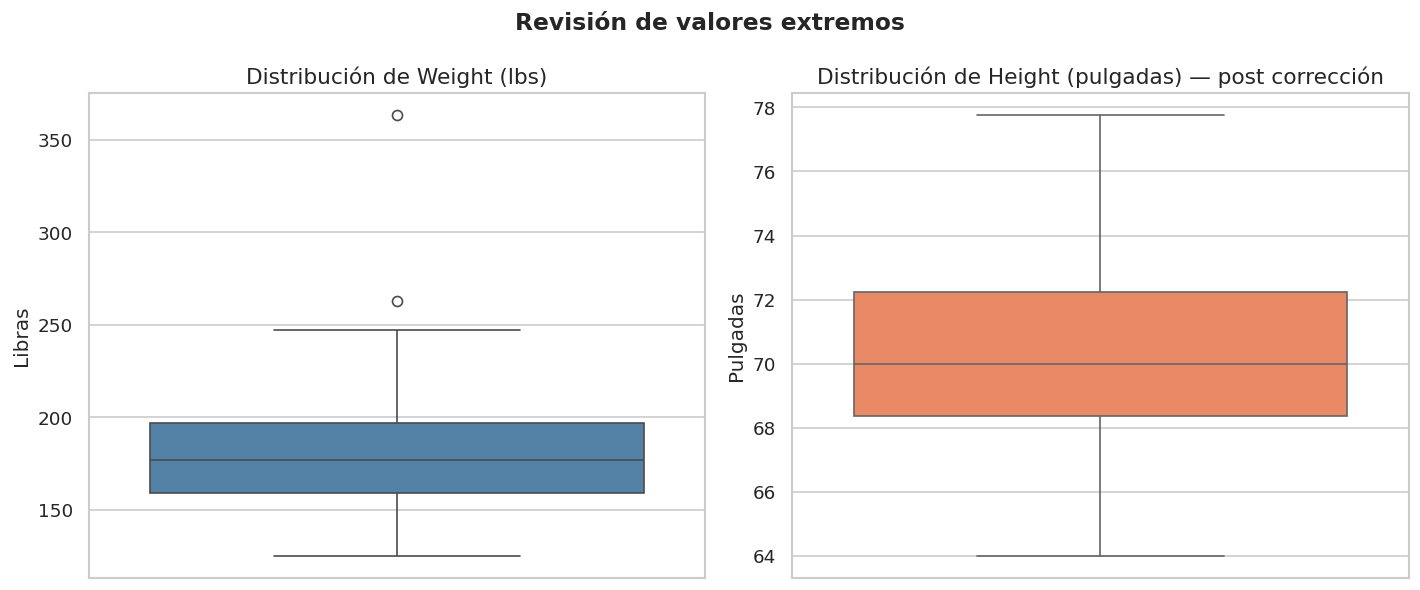

In [11]:
# Boxplots de Weight y Height para visualizar outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_clean['Weight'], ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Weight (lbs)', fontsize=13)
axes[0].set_ylabel('Libras')

sns.boxplot(y=df_clean['Height'], ax=axes[1], color='coral')
axes[1].set_title('Distribución de Height (pulgadas) — post corrección', fontsize=13)
axes[1].set_ylabel('Pulgadas')

plt.suptitle('Revisión de valores extremos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Distribución del Target — BodyFat

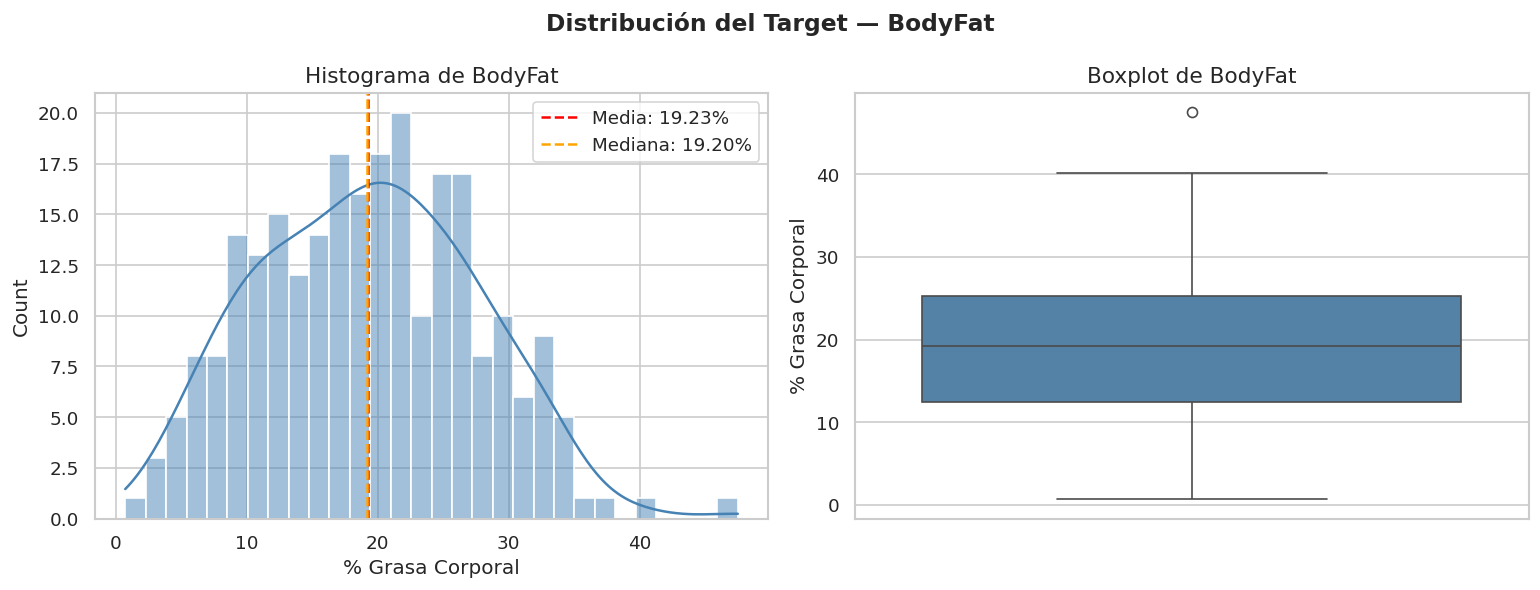

Asimetría (skewness): 0.1725  → leve sesgo positivo
Curtosis (kurtosis) : -0.3513


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma con KDE
sns.histplot(df_clean['BodyFat'], bins=30, kde=True, color='steelblue',
             edgecolor='white', ax=axes[0])
axes[0].axvline(df_clean['BodyFat'].mean(), color='red', linestyle='--',
                label=f'Media: {df_clean["BodyFat"].mean():.2f}%')
axes[0].axvline(df_clean['BodyFat'].median(), color='orange', linestyle='--',
                label=f'Mediana: {df_clean["BodyFat"].median():.2f}%')
axes[0].set_title('Histograma de BodyFat', fontsize=13)
axes[0].set_xlabel('% Grasa Corporal')
axes[0].legend()

# Boxplot
sns.boxplot(y=df_clean['BodyFat'], color='steelblue', ax=axes[1])
axes[1].set_title('Boxplot de BodyFat', fontsize=13)
axes[1].set_ylabel('% Grasa Corporal')

plt.suptitle('Distribución del Target — BodyFat', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas de asimetría
skewness = df_clean['BodyFat'].skew()
kurtosis = df_clean['BodyFat'].kurt()
print(f'Asimetría (skewness): {skewness:.4f}  → {"leve sesgo positivo" if skewness > 0 else "leve sesgo negativo"}')
print(f'Curtosis (kurtosis) : {kurtosis:.4f}')

### 7. Matriz de Correlación — Heatmap

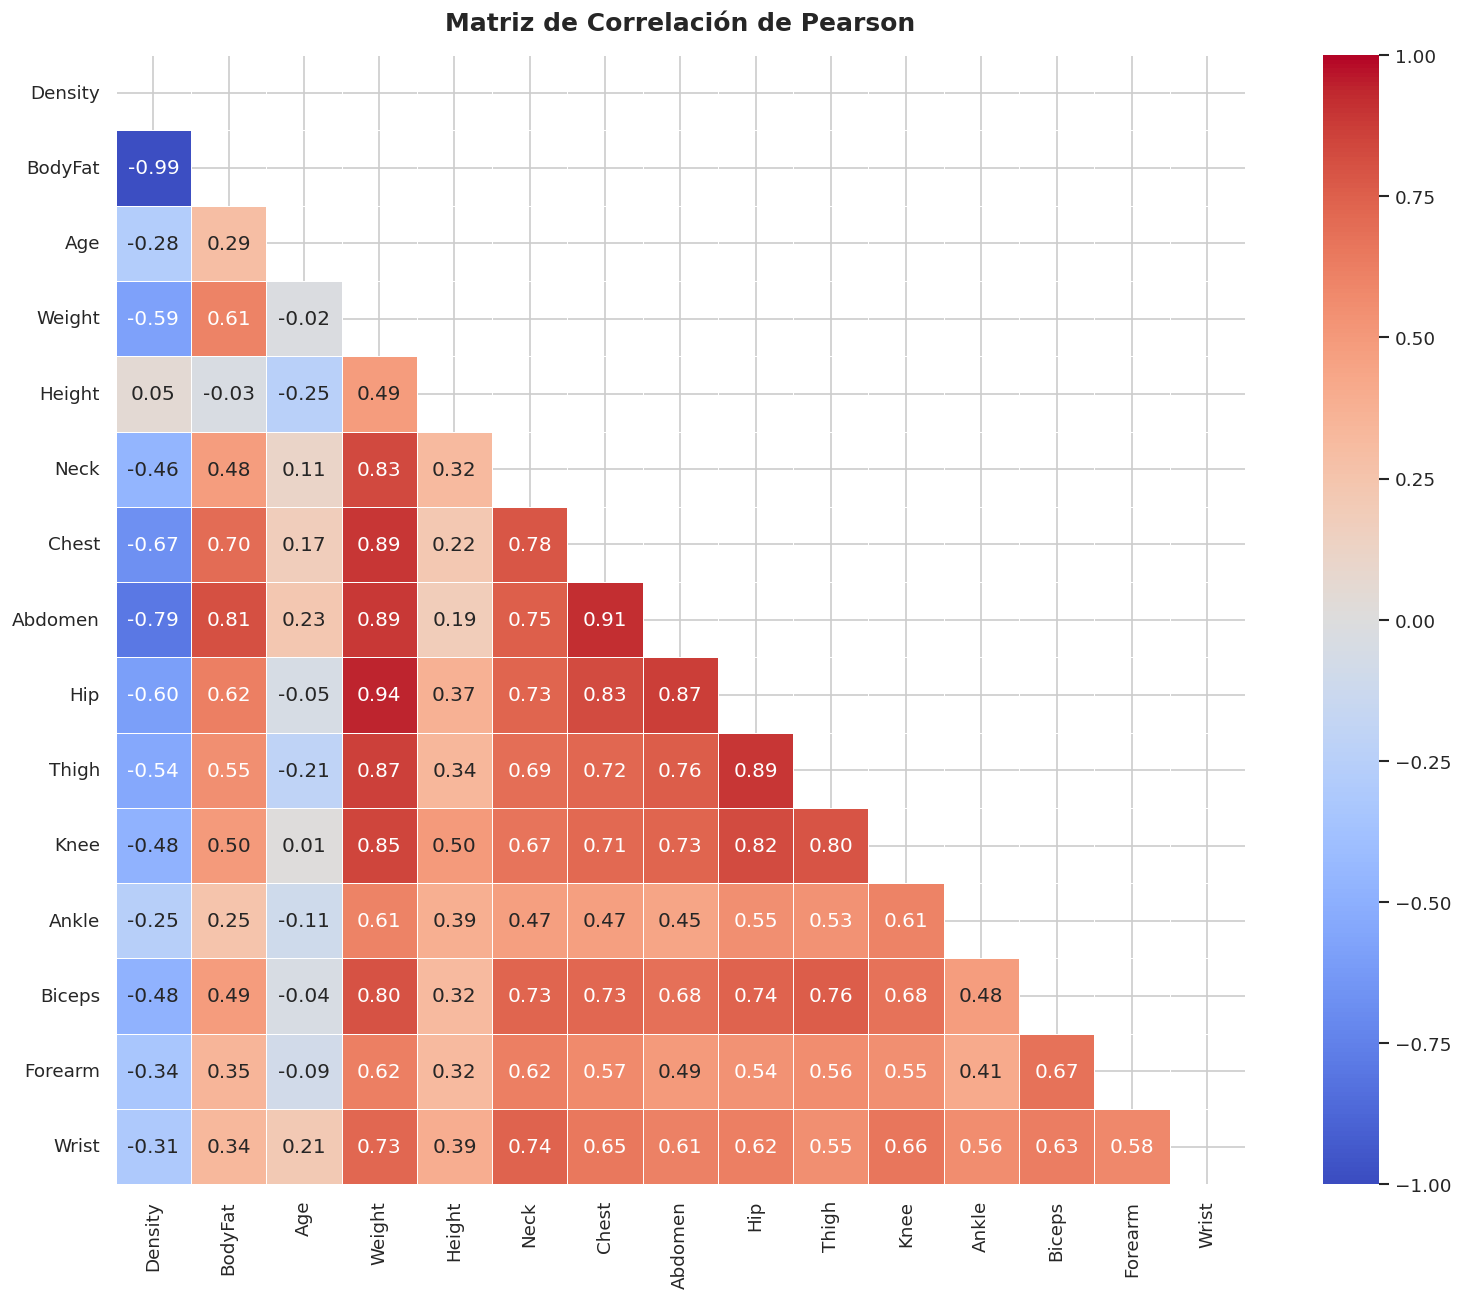

In [13]:
# Calculamos la matriz de correlación de Pearson
corr_matrix = df_clean.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title('Matriz de Correlación de Pearson', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

=== Correlación con BodyFat (descendente) ===
Abdomen    0.809725
Chest      0.695607
Hip        0.617980
Weight     0.605048
Thigh      0.550033
Knee       0.499019
Biceps     0.486752
Neck       0.482739
Forearm    0.349466
Wrist      0.335434
Age        0.291061
Ankle      0.254455
Height    -0.032532
Density   -0.988010


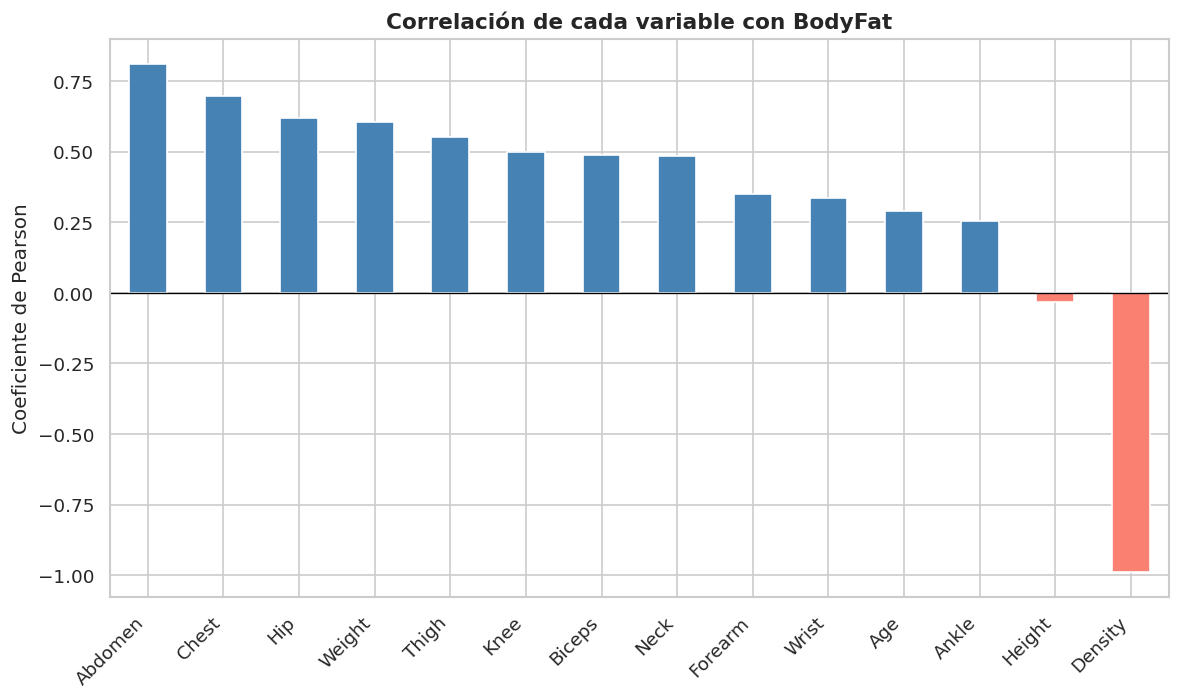

In [14]:
# Correlación de cada variable con BodyFat — ordenada
corr_target = corr_matrix['BodyFat'].drop('BodyFat').sort_values(ascending=False)

print('=== Correlación con BodyFat (descendente) ===')
print(corr_target.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'salmon' for v in corr_target.values]
corr_target.plot(kind='bar', color=colors, edgecolor='white', ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada variable con BodyFat', fontsize=13, fontweight='bold')
ax.set_ylabel('Coeficiente de Pearson')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
# Identificar pares de predictores con alta multicolinealidad (|r| > 0.85)
print('=== Pares con alta multicolinealidad (|r| > 0.85, excl. Density) ===')
predictores = [c for c in df_clean.columns if c not in ['BodyFat', 'Density']]
corr_pred = df_clean[predictores].corr()

pares_altos = []
for i in range(len(predictores)):
    for j in range(i+1, len(predictores)):
        r = corr_pred.iloc[i, j]
        if abs(r) > 0.85:
            pares_altos.append((predictores[i], predictores[j], round(r, 3)))

pares_df = pd.DataFrame(pares_altos, columns=['Variable 1', 'Variable 2', 'r'])
pares_df = pares_df.sort_values('r', ascending=False)
print(pares_df.to_string(index=False))

=== Pares con alta multicolinealidad (|r| > 0.85, excl. Density) ===
Variable 1 Variable 2     r
    Weight        Hip 0.940
     Chest    Abdomen 0.914
       Hip      Thigh 0.894
    Weight      Chest 0.892
    Weight    Abdomen 0.886
   Abdomen        Hip 0.872
    Weight      Thigh 0.866
    Weight       Knee 0.851


### 8. Análisis Bivariado — Scatter plots vs BodyFat

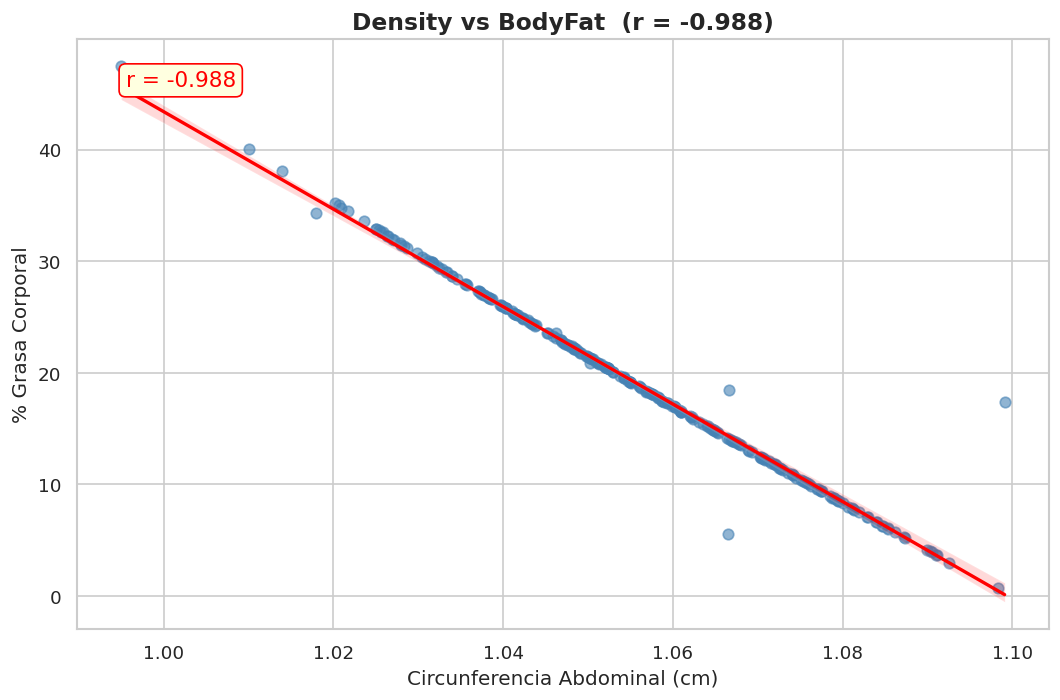

In [25]:
# Scatter plot destacado: Abdomen vs BodyFat (predictor más fuerte)
fig, ax = plt.subplots(figsize=(9, 6))

r_abd = corr_matrix.loc['Density', 'BodyFat']

sns.regplot(
    data=df_clean, x='Density', y='BodyFat',
    scatter_kws={'alpha': 0.6, 's': 40, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=ax
)

ax.set_title(f'Density vs BodyFat  (r = {r_abd:.3f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Circunferencia Abdominal (cm)', fontsize=12)
ax.set_ylabel('% Grasa Corporal', fontsize=12)
ax.annotate(f'r = {r_abd:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=13, color='red',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red'))

plt.tight_layout()
plt.show()

Top 6 predictores: ['Abdomen', 'Chest', 'Hip', 'Weight', 'Thigh', 'Knee']


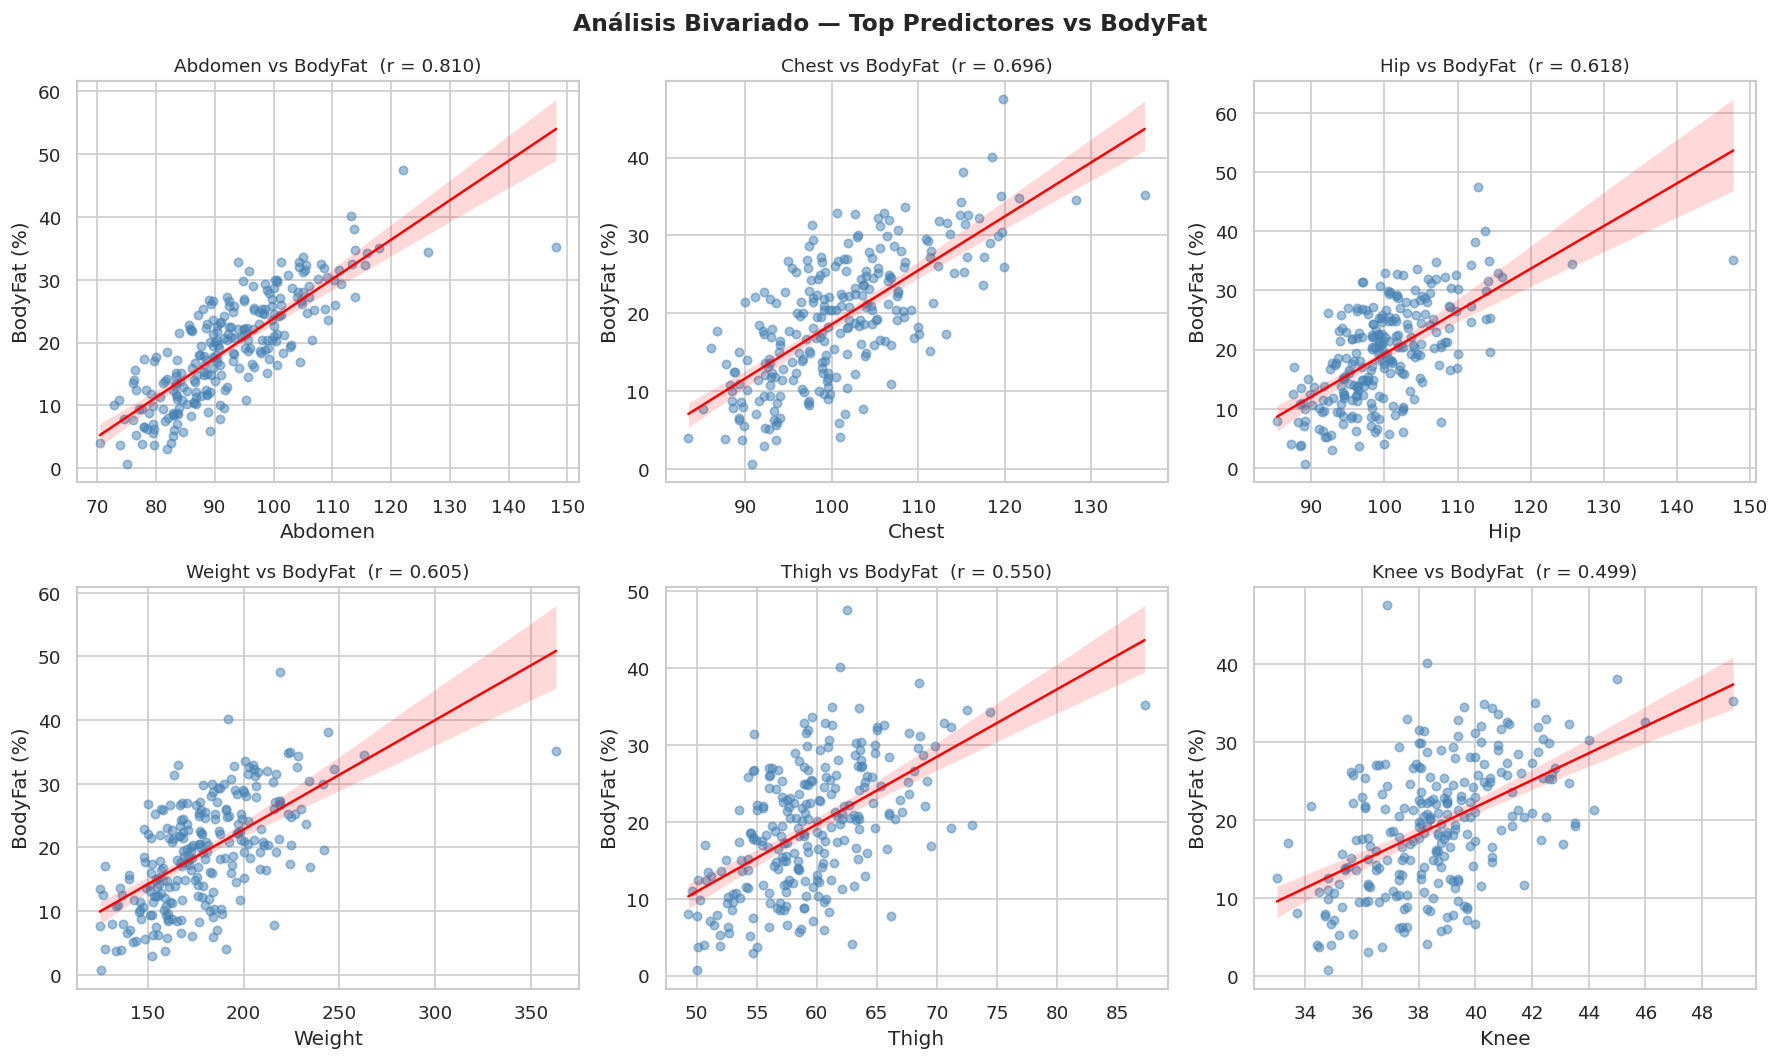

In [16]:
# Top 6 predictores más correlacionados con BodyFat (excluyendo Density)
top_vars = corr_target.drop('Density', errors='ignore').abs().sort_values(ascending=False).head(6).index.tolist()
print(f'Top 6 predictores: {top_vars}')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    r = corr_matrix.loc[var, 'BodyFat']
    sns.regplot(
        data=df_clean,
        x=var,
        y='BodyFat',
        ax=axes[i],
        scatter_kws={'alpha': 0.5, 's': 25, 'color': 'steelblue'},
        line_kws={'color': 'red', 'linewidth': 1.5}
    )
    axes[i].set_title(f'{var} vs BodyFat  (r = {r:.3f})', fontsize=11)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('BodyFat (%)')

plt.suptitle('Análisis Bivariado — Top Predictores vs BodyFat', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

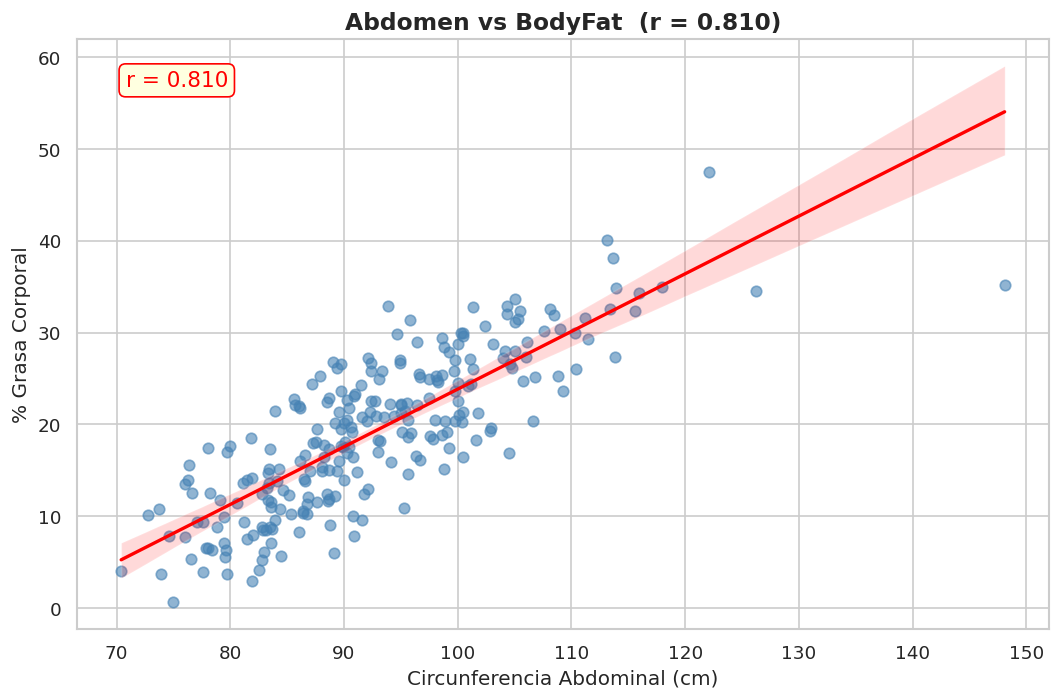

In [17]:
# Scatter plot destacado: Abdomen vs BodyFat (predictor más fuerte)
fig, ax = plt.subplots(figsize=(9, 6))

r_abd = corr_matrix.loc['Abdomen', 'BodyFat']

sns.regplot(
    data=df_clean, x='Abdomen', y='BodyFat',
    scatter_kws={'alpha': 0.6, 's': 40, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=ax
)

ax.set_title(f'Abdomen vs BodyFat  (r = {r_abd:.3f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Circunferencia Abdominal (cm)', fontsize=12)
ax.set_ylabel('% Grasa Corporal', fontsize=12)
ax.annotate(f'r = {r_abd:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=13, color='red',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red'))

plt.tight_layout()
plt.show()

### 3. Gráfico de pares (Pair Plot)

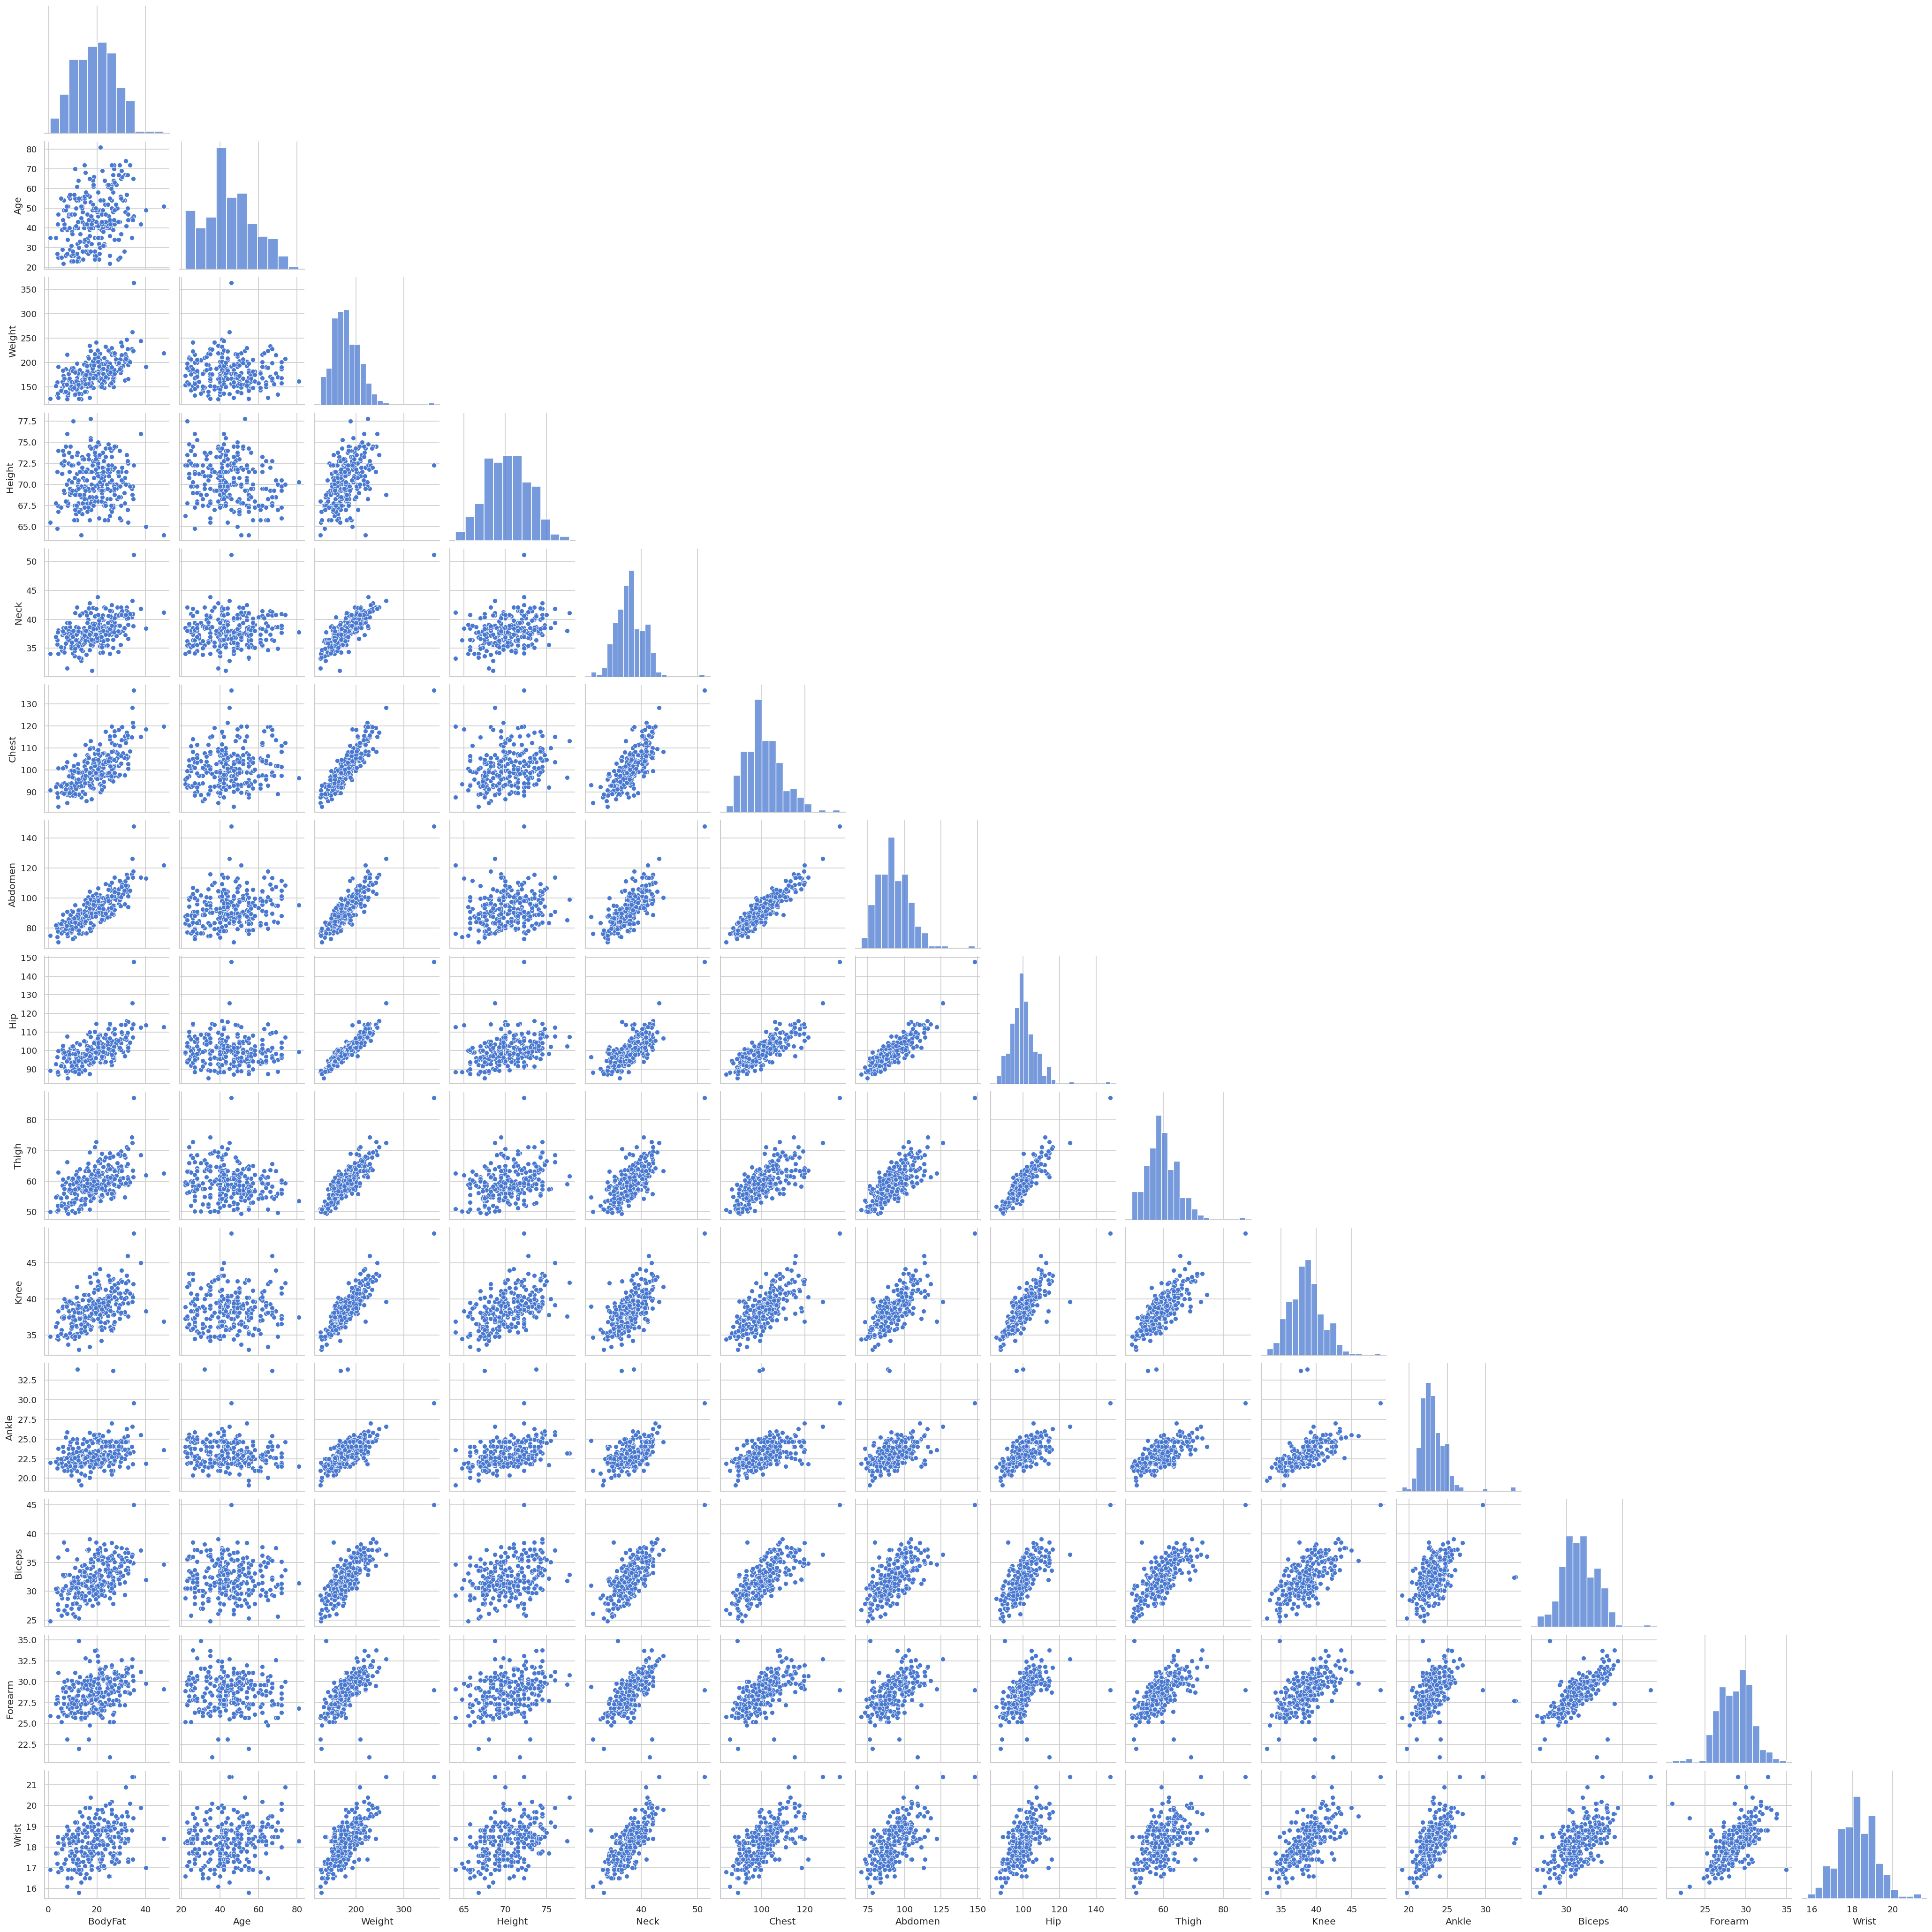

In [ ]:
# Generamos el gráfico de pares (Pair Plot) para visualizar relaciones multivariadas
df_final = df_clean.drop(columns="Density")
sns.pairplot(df_final, corner=True)
plt.show()

---
## Resumen del EDA

| Hallazgo | Detalle | Acción tomada |
|---|---|---|
| BodyFat = 0.0 | Biológicamente imposible | Fila eliminada |
| Height = 29.5 pulgadas | Error de tipeo evidente (~75 cm) | Imputado con mediana (70") |
| Weight = 363.15 lbs | Extremo pero plausible | Conservado |
| Multicolinealidad alta | Chest, Abdomen, Hip, Weight muy correlacionados entre sí | A considerar en modelado (PCA, Ridge, Lasso) |
| Predictor más fuerte | Abdomen (r ≈ 0.81 con BodyFat) | Priorizar en modelos lineales |
| Distribución BodyFat | Leve sesgo positivo, outliers en valores altos | Posible transformación log si es necesario |

**Próximos pasos pensados:**

Antes de pasar a la próxima Fase sacar Density por dataleakeage.

### Fase 3: Preprocesamiento de Datos

9. *Data Splitting:* Usa train_test_split para separar en conjuntos de entrenamiento y prueba (un split clásico de 80/20 está bien). Fija el random_state para asegurar la reproducibilidad de tus resultados.
10. *Tratamiento de Outliers:* Aplica la decisión tomada en los pasos 4 y 5. Dado que n=252 es un tamaño de muestra muy pequeño, prioriza corregir/imputar antes que eliminar filas si es posible.
11. *Separación de variables:* Divide tu dataset en la matriz de características X (excluyendo BodyFat y muy probablemente Density) y tu vector objetivo y (BodyFat).
12. *Escalado de features:* Aplica StandardScaler a tus datos. Como muchas medidas están en distintas escalas (peso en libras, altura en pulgadas, circunferencias en cm), esto es crucial para algoritmos que dependen de distancias o regularización. Regla de oro: Fit solo en train, transform en train y test.


### Fase 4: Modelado - ¿Algoritmos Lineales?

13. *Métricas de Evaluación:* Define tus KPIs. Para este problema de regresión, utiliza Error Cuadrático Medio (RMSE), Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²). ¿Algo más? 
14. *Modelo Baseline:* Crea un modelo ingenuo (dummy) que siempre prediga la media de la grasa corporal del set de entrenamiento. Todo modelo de Machine Learning que entrenes debe superar este umbral.
15. *Modelo Regularizado (Lasso):* Entrena una Regresión Lasso (Lasso). Elegimos Lasso sobre Ridge ya que al usar penalización L1, Lasso forzará a que los coeficientes de las variables menos importantes sean cero priorizando la simplicidad del modelo.

### Fase 5: Algoritmos No Lineales y Ensambles

16. *Support Vector Regressor (SVR):* Prueba este algoritmo (usando kernel lineal y RBF). Aquí el escalado que hiciste en el paso 12 demostrará su importancia.
17. *Random Forest:* Entrena un RandomForestRegressor. Este ensamble suele ser excelente para datos tabulares y maneja bien las relaciones no lineales sin tanto riesgo de sobreajuste inmediato como un solo árbol.
18. *Gradient Boosting:* Prueba un modelo de Boosting iterativo, como GradientBoostingRegressor o HistGradientBoostingRegressor (que es muy eficiente en Scikit-learn).

### Fase 6: Optimización y Validación Robusta

19. *Validación Cruzada (K-Fold):* Como tienes solo 252 muestras, el error en un solo split de test puede ser engañoso. Aplica cross_val_score con k=5 o k=10 en tus mejores modelos para obtener una estimación de rendimiento más robusta.
20. *Ajuste de Hiperparámetros:* Selecciona tus dos mejores modelos (por ejemplo, Lasso y Random Forest) y utiliza GridSearchCV para encontrar la combinación óptima de parámetros (ej. el valor alpha en Lasso o el n_estimators y max_depth en Random Forest).
21. *Evaluación Final y Análisis de Errores:* Evalúa el mejor modelo optimizado final contra el set de Test intacto. Extrae la importancia de las variables (usando feature_importances_ o los coeficientes) para explicar el modelo. Finalmente, grafica los residuos (Predicciones vs. Reales) para confirmar que el error es aleatorio y no hay patrones sistemáticos.